In [1]:
import open3d as o3d
import numpy as np

# ---------------------- 定义点云体素化函数 ----------------------
def get_mesh(_relative_path):
    mesh = o3d.io.read_triangle_mesh(_relative_path)
    mesh.compute_vertex_normals()
    o3d.visualization.draw_geometries([mesh])
    return mesh
# =============================================================
armadillo = o3d.data.ArmadilloMesh()
#bunny_mesh = o3d.data.BunnyMesh()
#knot_mesh = o3d.data.KnotMesh()
# ------------------------- Ball pivoting --------------------------
print("->Ball pivoting...")
_relative_path = armadillo.path    # 设置相对路径
N = 100000                        # 将点划分为N个体素
pcd = get_mesh(_relative_path).sample_points_poisson_disk(N)
o3d.visualization.draw_geometries([pcd])

radii = [0.008, 0.06, 0.07, 0.8]
rec_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, o3d.utility.DoubleVector(radii))
o3d.visualization.draw_geometries([rec_mesh])
# ==============================================================

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
->Ball pivoting...


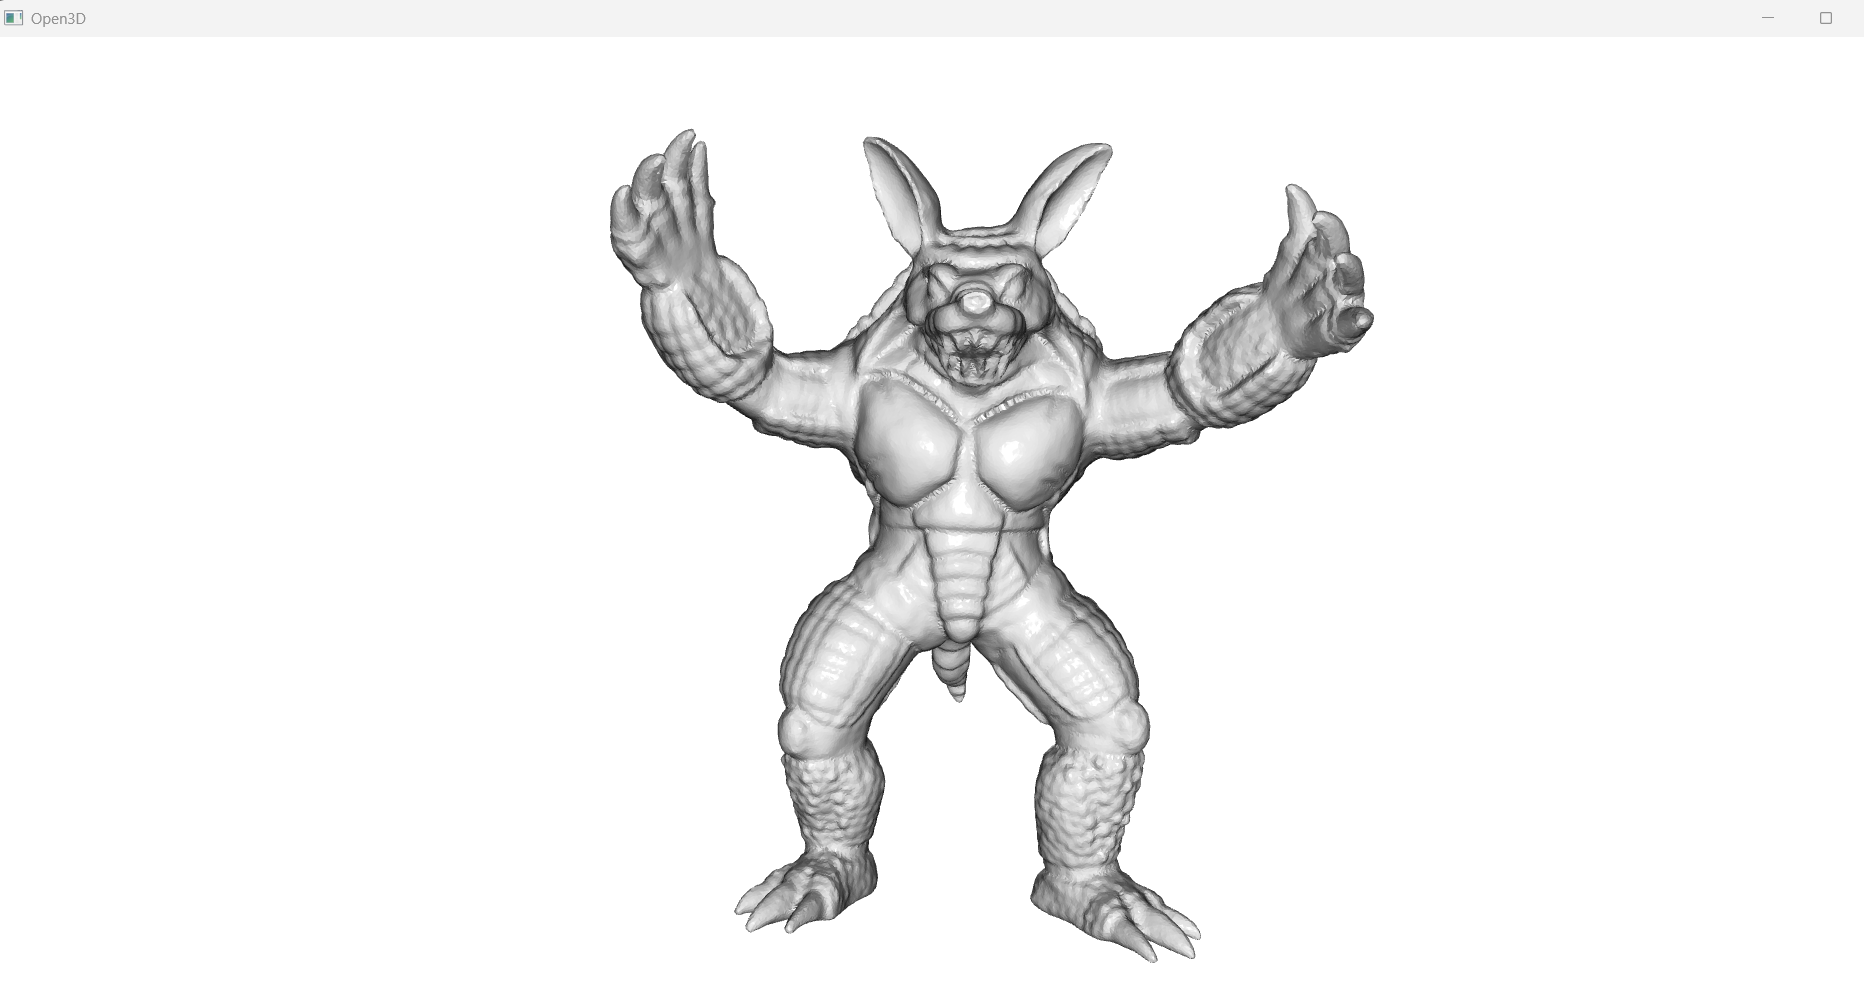

In [7]:
import open3d as o3d
import numpy as np

# -------------------------- 定義點雲體素化函式 ---------------------------
def get_mesh(_relative_path):
    mesh = o3d.io.read_triangle_mesh(_relative_path)
    mesh.compute_vertex_normals()
    return mesh
# =====================================================================

# -------------------- Poisson surface reconstruction ------------------
# 載入點雲
print("-> Poisson surface reconstruction...")
knot_mesh = o3d.data.KnotMesh()
_relative_path = knot_mesh.path    # 設定相對路徑
N = 6000                             # 將點雲採樣為 N 個點（Poisson disk sampling）
pcd = get_mesh(_relative_path).sample_points_poisson_disk(N)
pcd.normals = o3d.utility.Vector3dVector(np.zeros((1, 3)))  # 使現有法向量無效

# 法向量估計
pcd.estimate_normals()
o3d.visualization.draw_geometries([pcd], point_show_normal=True)

pcd.orient_normals_consistent_tangent_plane(100)
o3d.visualization.draw_geometries([pcd], point_show_normal=True)

# Poisson 重建
print("執行 Poisson 表面重建")
with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd, depth=9)

print(mesh)
o3d.visualization.draw_geometries([mesh])
# =====================================================================

-> Poisson surface reconstruction...
執行 Poisson 表面重建
[Open3D DEBUG] Input Points / Samples: 6000 / 6000
[Open3D DEBUG] #   Got kernel density: 0.03400015830993652 (s), 207.85546875 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] #     Got normal field: 0.02499985694885254 (s), 213.859375 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] Point weight / Estimated Area: 7.252612e-04 / 4.351567e+00
[Open3D DEBUG] #       Finalized tree: 0.04400014877319336 (s), 225.47265625 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] #  Set FEM constraints: 0.06299996376037598 (s), 218.31640625 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] #Set point constraints: 0.010999917984008789 (s), 218.42578125 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] Leaf Nodes / Active Nodes / Ghost Nodes: 371792 / 126840 / 298065
[Open3D DEBUG] Memory Usage: 218.426 MB
[Open3D DEBUG] # Linear system solved: 0.11300015449523926 (s), 219.62109375 (MB) / 239.88671875 (MB) / 409 (MB)
[Open3D DEBUG] Got avera

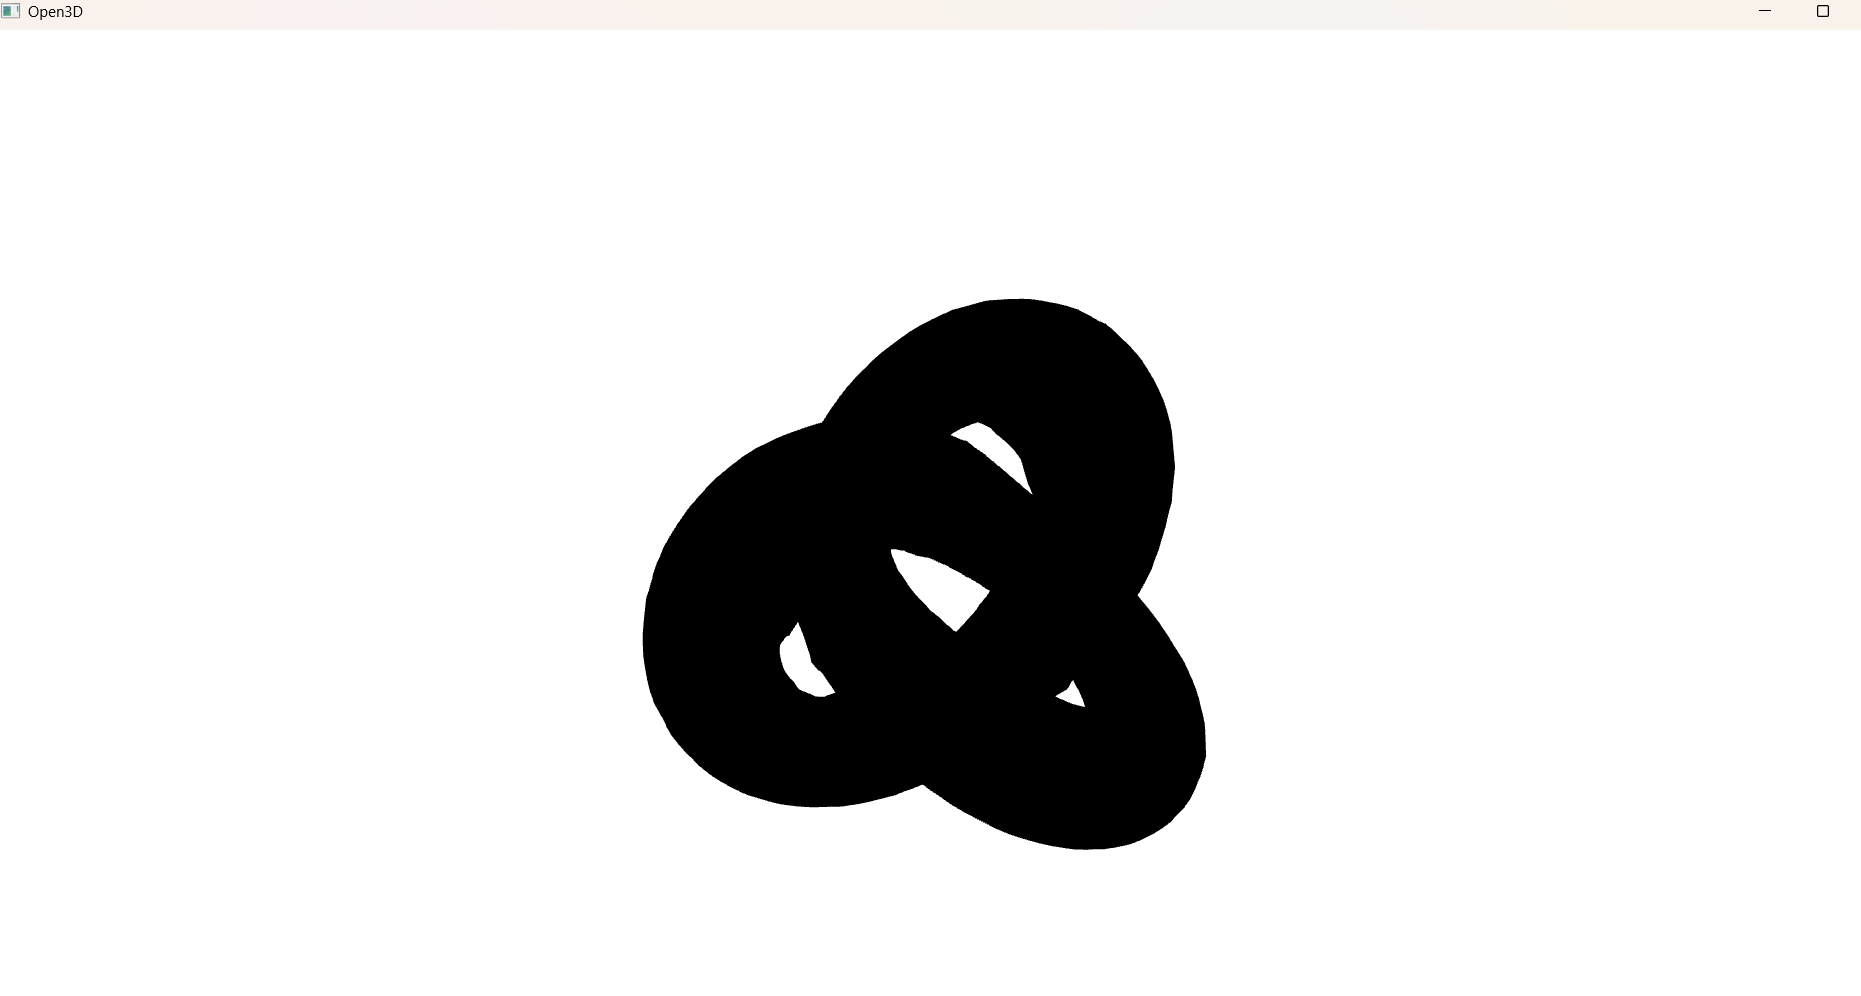